In [517]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn # To ignore some warnings from sklearn logistic regression
from sklearn.exceptions import ConvergenceWarning # To avoid logistic regression failing in case of perfect separation

import datetime
import numpy as np
from scipy.optimize import minimize # minimizing function for AIOLI
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
import pandas as pd
from sklearn.linear_model import LogisticRegression # for classic logistic regression
from typing import Literal
from sklearn.neighbors import KDTree # For Knn for SMOTE

options={"disp": False} # To not get verbose from minimize function

In [518]:
import ipywidgets

# Global variables

In [519]:
default_n = 200
default_runs = 5
default_test_ratio = 0.3

# Algorithms

## Helper functions for algorithms

First I define some functions that will be used later in all algorithms.

In [520]:
def sig(z):
    """ Sigmoid function that avoids overflow """
    if z < 0:
        return np.exp(z) / (1 + np.exp(z))
    else:
        return 1 / (1 + np.exp(-z))

In [521]:
# NOTE TO DO : put in general algorithm function that if radius == NA then this is not done.
def project_onto_l2_ball(x,radius):
    """ Euclidean projection onto L2 ball"""
    norm = np.linalg.norm(x)
    if norm <= radius:
        return x
    return x * radius/norm

In [522]:
def calculate_OTB(array, method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None, p = 0.5):
    """ Weighted average function
    ----
    Parameters:
        p: Proportion of last observations to average over. Ex p = 0.3 means average over last 30% of observations.
    Methods:
        Suffix averaging: Average over last p percentage of observations.
        Uniform: Average over all iterates equally
        Last iterate: Consider only the last iterate.
        """
    n = len(array)
    # Check p is a proportion
    if p is None:
        p = 0.5
    if not (0 <= p <= 1):
        raise ValueError("p must be between 0 and 1")

    match method:
        case "suffix_averaging":
            i = round((1-p)*n)
            result = np.mean(array[i:], axis=0)
        case "last_iterate":
            last_iterate = n - 1
            result = array[last_iterate]
        case _: # Uniform is default
            result = np.mean(array, axis=0)

    return result

In [523]:
def log_loss(betas,data_x,data_y):
    """ Works for a vector of betas and a whole dataset"""
    return np.sum(np.logaddexp(0,-data_y*np.inner(data_x,betas)))

In [524]:
def generate_x(n,d, correlated = False, means = None, sds = None, highly_correlated = False, seed = 40, standardized = False):
    seed_used = seed
    rng = np.random.default_rng(seed) # Random number generator
    x = []

    if sds is None:
        sds = rng.uniform(0.1,0.5,d)
    if means is None:
        means = [rng.normal(1,sd,1).item() for sd in sds]
    # Put variances in covariance matrix
    cov = np.diag(sds**2)

    if not correlated:
        x = rng.multivariate_normal(means,cov, size = n)
    if correlated:
        # Create off diagonal, triangular matrix
        off_diag = np.triu(rng.uniform(0,2, size = (d,d)))
        cov = cov + off_diag + off_diag.T
        x = rng.multivariate_normal(means,cov, size = n)
        if highly_correlated and d == 3:
            x1 = generate_x(n,1, seed = seed_used)
            x2 = x1 + rng.normal(2,1)
            x3 = x1 + x2
            x = np.concatenate((x1,x2,x3), axis = 1)

    if standardized:
        standardized_x = (x - np.mean(x, axis=0) ) / np.std(x, axis=0)
        x = standardized_x
    return x


In [525]:
generate_x(100,3, means = [2,2,1])

array([[ 1.59317144,  1.61280879,  1.36647191],
       [ 2.5439334 ,  1.65378522,  0.81281154],
       [ 2.07576924,  2.0545868 ,  0.66782066],
       [ 1.77635246,  1.64694256,  1.18407731],
       [ 2.12915839,  1.921681  ,  0.36326747],
       [ 2.01764196,  2.52471761,  1.20347101],
       [ 2.06475351,  2.0166069 ,  1.27803226],
       [ 1.84818143,  1.87923603,  0.75675575],
       [ 1.92584905,  1.77484725,  1.72560586],
       [ 2.28309454,  1.57426178,  1.11513966],
       [ 1.8939221 ,  2.38677869, -0.11144303],
       [ 2.24669663,  2.12399631,  0.67002761],
       [ 1.74945567,  1.86723779,  1.32932023],
       [ 2.27067636,  1.05546808,  1.76678388],
       [ 2.78852342,  1.89902049,  1.60025136],
       [ 1.66606497,  2.01934316,  1.39025936],
       [ 1.75511414,  2.34265121,  1.04068952],
       [ 2.25126166,  2.34099882,  1.26025517],
       [ 2.13631198,  1.39688535, -0.0380774 ],
       [ 1.98393365,  1.58851995,  0.79967789],
       [ 1.47083   ,  1.82516503,  1.055

In [526]:
def generate_y(n,x, betas, seed = 40, plot = False, method: Literal["sigmoid", "sinusoidal", "quadratic", "sig(1/x)", "only_x1_x2"] | None = None):
    y = np.zeros(n)
    prob_y1 = np.zeros(n)
    rng = np.random.default_rng(seed) # Random number generator

    match method:
        case "sinusoidal":
            prob_y1 = [(1/2)*np.sin(np.inner(x_t,betas))+1/2 for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "quadratic":
            prob_y1 = [sig(np.inner((x_t**2),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "sig(1/x)":
            prob_y1 = [sig(np.inner((1/x_t),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "only_x1_x2":
            x1_x2 = x[:,0:2]
            prob_y1 = [sig(np.inner(x1_x2_t,betas[0:2])) for x1_x2_t in x1_x2]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case _: # Sigmoid function is default
            prob_y1 = [sig(np.inner(x_t,betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

    # Graphs
    if plot:
        for i in range(x.shape[1]):
            sns.scatterplot(x = x[:,i].flatten(), y = prob_y1)
            plt.title(f"P(Y=1) over x{i}")
            plt.show()

    return np.array(y)

In [631]:
def generate_data(setting, balanced = True, seed = 30, n = 200, x_means = None):
    # Allocate space for variables
    x = []
    y = []
    betas = []

    # Define x means based on balanced or unbalanced setting
    x_means_simulation = [1,-2,0.85] if balanced else [2,1,5] # average sigmoid balanced: 0.5, unbalanced : 0.05
    x_means_simulation = x_means_simulation if x_means is None else x_means
    x = generate_x(n,3, means = x_means_simulation, seed = seed)
    # Generate data according to setup
    match setting:
        case "well specified":
            # Generate data
            betas = [0.4,-0.3,-1.2]
            y = generate_y(n,x,betas = betas, seed = seed)

        case "high dimensional":
            # Define betas and x means to fit high dimensionality
            betas = [2,0.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7] if balanced else [2,1.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7]
            x_means_simulation = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1] if balanced else [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]

            # Generate x again for the high dimensional setting
            y = generate_y(n,x,betas = betas, seed = seed)
        case "sinusoidal":
            betas = [0.4,-0.3,-1.2]
            y = generate_y(n,x,betas = betas, seed = seed, method = "sinusoidal")
        case "quadratic":
            betas = [0.4,-0.3,-1.2]
            y = generate_y(n,x,betas = betas, seed = seed, method = "quadratic")

    d = len(x_means_simulation)
    av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)

    print(f"{n} samples were generated in the {setting} {"balanced" if balanced else "unbalanced"} setting. Using {d} variables, with an average sigma of {av_sigma}")

    # Make train/test split
    test_size = round(default_test_ratio*n)

    x_train = x[:test_size]
    y_train = y[:test_size]
    x_test = x[test_size:]
    y_test = y[test_size:]

    return x_train, y_train, x_test, y_test

In [527]:
a = generate_x(100,3, means = [2,2,1])
generate_y(100, x = a, betas = [2,1,0.1],method = "sinusoidal" )


array([-1,  1, -1,  1, -1, -1,  1, -1, -1, -1,  1,  1, -1,  1,  1, -1,  1,
        1, -1,  1, -1, -1, -1, -1, -1,  1,  1, -1,  1, -1, -1,  1,  1,  1,
        1, -1,  1,  1, -1,  1, -1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,
       -1,  1, -1,  1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1, -1,  1, -1,
        1, -1, -1,  1, -1,  1,  1, -1, -1,  1,  1, -1,  1, -1, -1, -1,  1,
       -1, -1, -1,  1, -1,  1, -1, -1,  1, -1, -1,  1, -1, -1, -1])

### X means and betas for balanced data $P(Y=1) = 0.5)$

In [528]:
# Balanced
bs_balanced = [2,0.1,-4.2]
xs_balanced = [2,2,1]
print(np.inner(bs_balanced,xs_balanced))
print(sig(np.inner(bs_balanced,xs_balanced)))
print((1/2)*np.sin(np.inner(xs_balanced,bs_balanced)) + 1/2)

0.0
0.5
0.5


In [529]:
#balanced quadratic
xs_balanced_quadratic = np.array([1.45,0.5,1])
print(sig(np.inner(bs_balanced,xs_balanced_quadratic**2)))


0.5074994375506204


In [530]:
# Balanced High dimensional (25 variables)
bs_hd_balanced = [2,0.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7]

xs_hd_balanced = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]


print(len(bs_hd_balanced), len(xs_hd_balanced))
print(np.inner(bs_hd_balanced,xs_hd_balanced))
print(sig(np.inner(bs_hd_balanced,xs_hd_balanced)))
print((1/2)*np.sin(np.inner(xs_hd_balanced,bs_hd_balanced)) + 1/2)

25 25
-0.02000000000000135
0.49500016665999996
0.4900006666533328


### Test functions

In [531]:
hola = generate_x(200,2, means = [0.5,1.2])

In [532]:
adios = generate_y(200,generate_x(200,2, means = [0.5,1.2]),[0.1,0.3], method = "sinusoidal", plot = False)
# adios2 = generate_y(200,generate_x(200,3, means = xs_balanced),bs_balanced, method = "sinusoidal", plot = True)
print(sum(adios == 1))
print(sum(adios == -1))

144
56


## Online Gradient Descent

In [533]:
def online_gd(data_y, data_x, B, OTB_method = None, OTB_average_proportion = None):
    """Online gradient descent
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B: float
        Radius of the L2 ball constraint for the parameter vector beta
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.

    loss = np.zeros(n)
    G = 1 # Max gradient
    eta = 1
    gradient = np.zeros(d)
    y_hat = np.zeros(n)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = betas[t-1] - eta*gradient

        # Euclidean projection of beta onto the L2 ball
        #betas[t] = project_onto_l2_ball(beta_tilde,B)
        betas[t] = beta_tilde

        # Issue prediction
        y_hat[t] = sig(np.inner(betas[t],xt))

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        # update maximum gradient
        G = np.max([G,np.linalg.norm(gradient)**2])

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Recalculate eta
        eta = 1 / np.sqrt((t+1) * G) # Here t+1 simply because python initializes t to 0


    # Store endtime
    end_time =  datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas,
        "predictions": y_hat
    }


### Testing ODG

In [534]:
#ogd = online_gd(n = 40,d = 3,data_y = y,data_x = x,B = 40)

## AIOLI

In [535]:
class AIOLI:
    def __init__(self):
        self.first_sum  = []
        self.etas_gradients = []
        self.x0 = [] # Initializer for minimizing algorithm
        self.reg_lambda = 0
        self.train_size = 0
        self.d = 0
        self.n = 0

    # Define function to minimize for AIOLI
    @staticmethod # Because I dont use the self
    def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
        l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
        # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
        result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
        return result

    def new_point_loss(self,X,Y, OTB_method):
        convergence_new = 0
        beta_hat = np.zeros((self.train_size,self.d))
        first_sum  = np.zeros(self.d)
        etas_gradients = np.zeros((self.d,self.d))
        for t in range(self.train_size):
            # Minimize using data up until t-1
            result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
            beta_hat[t] = result.x
            convergence_new += result.success
            # Update minimization elements for next round
            first_sum += self.first_sum[t]
            etas_gradients += self.etas_gradients[t]

        # Get OTB
        big_beta = calculate_OTB(beta_hat, OTB_method)

        # Suffer loss
        loss_point = np.logaddexp(0,-Y*np.inner(X,big_beta))

        return loss_point

    def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
        start_time = datetime.datetime.now()
        new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
        end_time = datetime.datetime.now()
        return{
                "runtime" : (end_time - start_time).total_seconds(),
                "loss" : sum(new_losses)
            }


    def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b", dynamic_B = False):
        """AIOLI
        This is the function to run AIOLI.

        Parameters
        ---------
        data_y : ndarray
            Vector with outcome(y) values. Dimensions: n x 1
        data_x: ndarray
            Array with independent variables. Dimensions: n x d
        B: float
            Radius of the L2 ball constraint for the parameter vector beta
        X: float
            Radius of the L2 ball constraint for the feature vector x"""
        # Record start time
        start_time = datetime.datetime.now()

        # Get data dimensions
        self.n = data_x.shape[0]
        n = self.n
        self.d = data_x.shape[1]
        d = self.d
        self.x0 = np.zeros(d) # Initializer for minimizing algorithm
        self.train_size = n
        # Initialize vectors for storage
        betas = np.zeros((n, d))
        ys = np.zeros(n)
        y_hats = np.zeros(n)
        loss = np.zeros(n)
        etas = np.zeros(n)
        gradients = np.zeros((n, d))
        self.reg_lambda = 1 / (B**2)

        # Keep sums for loss functions
        self.first_sum  = np.zeros((n, d))
        self.etas_gradients = np.zeros((n,d,d))
        first_sum  = np.zeros(d)
        etas_gradients = np.zeros((d,d))

        # Track convergence
        convergence = 0
        minimizer_gradient = 0

        # Run Algorithm
        for t in range(n):
            # Get context vector
            xt = data_x[t]

            # Update beta parameter
            # noinspection PyTypeChecker # This is to avoid the underlining which
            if t == 0: # Initialize to 0 for first round
                betas[t] = np.zeros(d)
            else:
                result = minimize(self.parameter_function_AIOLI,
                                  np.zeros(d),
                                  method = minimize_method,
                                  args=(xt, self.reg_lambda,first_sum, etas_gradients),
                                  options = {"maxiter":100000}
                                  )
                betas[t] = result.x
                convergence += result.success
                minimizer_gradient += np.linalg.norm(result.jac)

            # # Project beta onto set
            # betas[t] = project_onto_l2_ball(beta_tilde,B)
            # betas[t] = self.x0

            # Generate prediction
            y_hats[t] = np.inner(xt,betas[t])

            # Observe true y from data
            ys[t] = data_y[t]

             # Compute gradient
            gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))

            # Estimate eta
            etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)

            # Suffer loss
            loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))

            # Compute elements for AIOLI loss function

            fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
            eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
            self.first_sum[t] = fs
            self.etas_gradients[t] = eg
            first_sum += fs
            etas_gradients += eg
            # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.

            # Dynamic Hyperparameter tuning
            if dynamic_B:
                B = max(B, np.linalg.norm(betas[t]))

        # for loop ends

        # Get Batch estimate
        betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

        # Get Batch estimate loss
        loss_OTB = log_loss(betas_OTB,data_x, data_y)

        end_time = datetime.datetime.now()

        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "Total_Loss" : loss_OTB,
            "Online_Loss" : sum(loss),
            "Batch_estimate": betas_OTB,
            "All_Betas": betas,
            "convergence" : convergence,
            "minimizer_gradient" : minimizer_gradient
        }



### Testing AIOLI

### AIOLI convergence check

In [347]:
aioli_model = AIOLI()
aioli_results_nondynamic = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 1, minimize_method = "l-bfgs-b", dynamic_B = False)
aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

np.float64(2.7887864633800703)

In [332]:
aioli_model = AIOLI()
aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 40, minimize_method = "l-bfgs-b", dynamic_B = True)
aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

C:\Users\marie\AppData\Local\Temp\ipykernel_14136\1091268577.py:128: RuntimeWarning: overflow encountered in exp
  etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)
C:\Users\marie\AppData\Local\Temp\ipykernel_14136\1091268577.py:136: RuntimeWarning: invalid value encountered in multiply
  eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
C:\Users\marie\AppData\Local\Temp\ipykernel_14136\1091268577.py:14: RuntimeWarning: invalid value encountered in dot
  l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
C:\Users\marie\AppData\Local\Temp\ipykernel_14136\1091268577.py:16: RuntimeWarning: invalid value encountered in logaddexp
  result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2


np.float64(2.6970561187040785)

In [191]:
minimization_methods = ["l-bfgs-b",'bfgs',"CG"]

for method in minimization_methods:
    aioli_model = AIOLI()
    aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 5, minimize_method = method)
    print(f"Method: {method}")
    print(f"convergence: {aioli_results["convergence"]}")
    print(f"minimizer_gradient: {aioli_results["minimizer_gradient"]}")
    print(f"Online loss: {aioli_results["Online_Loss"]}")


Method: l-bfgs-b
convergence: 9
minimizer_gradient: 0.0006153743028201643
Online loss: 6.931471805599453
Method: bfgs
convergence: 5
minimizer_gradient: 0.0005104082623348745
Online loss: 6.931471805599453
Method: CG
convergence: 5
minimizer_gradient: 0.00038914593673456885
Online loss: 6.931471805599453


In [192]:
aioli_model.new_data_loss(new_data_x = x_test, new_data_y = y_test, OTB_method = "uniform")

{'runtime': 0.21792, 'loss': np.float64(2.4561177978110798)}

## Ada Grad

In [536]:
def online_AdaGrad(data_y, data_x, B_vector, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B_vector: array
        Hyperparemeter, originally represents
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    loss = np.zeros(n)
    sum_gradient_square = np.zeros(d)

    for t in range(n):
        # Receive x and y
        xt = data_x[t]
        yt = data_y[t]

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        sum_gradient_square += gradient**2

        # Output betas
        if t == (n-1):
            pass
        else:
            for i in range(d):
                if gradient[i] != 0:
                    eta_ti = (np.sqrt(2)*B_vector[i])/(2*np.sqrt(sum_gradient_square[i]))
                    betas[t+1,i] = betas[t,i] - eta_ti*gradient[i]
                else:
                    betas[t+1,i] = betas[t,i]

    # Store endtime
    end_time = datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


In [537]:
def projected_online_AdaGrad(data_y, data_x, B_vector, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B_vector: array
        Hyperparemeter, originally represents
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    loss = np.zeros(n)
    sum_gradient_square = np.zeros(d)
    b_min = - B_vector / 2
    b_max = B_vector / 2

    for t in range(n):
        # Receive x and y
        xt = data_x[t]
        yt = data_y[t]

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        sum_gradient_square += gradient**2

        # Output betas
        if t == (n-1):
            pass
        else:
            for i in range(d):
                if gradient[i] != 0:
                    eta_ti = (np.sqrt(2)*B_vector[i])/(2*np.sqrt(sum_gradient_square[i]))
                    betas[t+1,i] = max(min(betas[t,i] - eta_ti*gradient[i],b_min[i]),b_max[i])
                else:
                    betas[t+1,i] = betas[t,i]

    # Store endtime
    end_time = datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


In [196]:
x = generate_x(150,3, means= [2,2,1])
betas = [2,20,-4.2]
y = generate_y(150,x,betas = betas)

x_train = x[:100]
y_train = y[:100]
x_test = x[100:]
y_test = y[100:]

standardized_x_train = (x_train - np.mean(x_train, axis=0) ) / np.std(x_train, axis=0)
#x_train = standardized_x_train

In [197]:
ag_trial = online_AdaGrad(y_train, x_train, np.repeat(40/13,3))
ag_trial
print(log_loss(ag_trial["Batch_estimate"],x_test,y_test))
ag_u = calculate_OTB(ag_trial["All_Betas"], "uniform")
ag_s  = calculate_OTB(ag_trial["All_Betas"], "suffix_averaging")
ag_li  = calculate_OTB(ag_trial["All_Betas"], "last_iterate")
print(f"{log_loss(ag_u,x_test,y_test)}, {log_loss(ag_s,x_test,y_test)},  {log_loss(ag_li,x_test,y_test)}" )


3.514437251663476
3.514437251663476, 4.573952634660621,  4.786605559934853


In [198]:
og_trial = online_gd(y_train, x_train, 40)
og_trial
log_loss(og_trial["Batch_estimate"],x_test,y_test)

np.float64(7.698978531809346)

Hyperparemeter tuning Ada Grad

In [490]:
B_values_adagrad = [x for x in range(1, 60, 4)]
loss_B_adagrad = np.zeros(len(B_values_adagrad))

for i in range(len(B_values_adagrad)):
    adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(B_values_adagrad[i],3))
    ag_u = calculate_OTB(adagrad["All_Betas"], "uniform")
    ag_s  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
    ag_li  = calculate_OTB(adagrad["All_Betas"], "last_iterate")
    print(f"{log_loss(ag_u,x_test,y_test)}, {log_loss(ag_s,x_test,y_test)},  {log_loss(ag_li,x_test,y_test)}" )

    loss_B_adagrad[i] = log_loss(ag_u, x_test, y_test)


<Axes: xlabel='B_value', ylabel='Loss'>

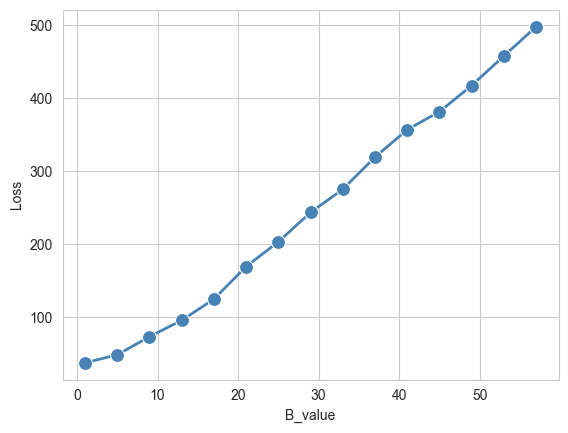

In [491]:
# Create DataFrame for seaborn
df = pd.DataFrame({
    'B_value': B_values_adagrad,
    'Loss': loss_B_adagrad
})

# Line plot with markers
sns.lineplot(data=df, x='B_value', y='Loss', marker='o', markersize=10,
             linewidth=2, color='steelblue')

## Logistic Regression

In [199]:
def classic_logistic_regression(data_x, data_y):
    # Using safe implementation where if data is perfectly separable, then it's just fit minimizing the logistic loss.
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty=None, fit_intercept=False, max_iter=10000)

    try:
        logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        # Single class case: fit manually using scipy minimize on the logistic loss
        def logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores))

        result = minimize(logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Logistic regression was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [200]:
# def classic_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty=None, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Ridge Logistic Regression

In [201]:
def ridge_logistic_regression(data_x, data_y, reg_lambda=1.0):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l2', C=1/reg_lambda, fit_intercept=False, max_iter=10000, random_state=1)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def ridge_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.linalg.norm(b)**2

        result = minimize(ridge_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Ridge LG was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [202]:
# def ridge_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty="l2", random_state=1, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Lasso Logistic Regression

In [203]:
def lasso_logistic_regression(data_x, data_y, reg_lambda=1.0):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l1', C=1/reg_lambda, fit_intercept=False, max_iter=10000, random_state=1)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def lasso_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.abs(np.linalg.norm(b, ord = 1))

        result = minimize(lasso_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Lasso LG was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

## Sample Minmax Predictor (SMP)

In [204]:
class sample_minmax_predictor():
    def __init__(self,data_x, data_y):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = sig(1*np.inner(beta_hat_y1,new_x)) / ( sig(np.inner(beta_hat_y1,new_x)*1) + sig(np.inner(beta_hat_y_1,new_x)*(-1)) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : sum(new_losses),
            "loss_t" : new_losses
        }


### Testing SMP

In [205]:
smp = sample_minmax_predictor(x_train, y_train)
smp.get_new_loss(x_test, y_test)

{'runtime': 0.661763,
 'loss': np.float64(2.810883048173729),
 'loss_t': [np.float64(0.6931471208922974),
  np.float64(0.0022846379747213353),
  np.float64(0.11662633519489893),
  np.float64(0.001045841289610739),
  np.float64(0.041570490976528776),
  np.float64(0.00020387896822988893),
  np.float64(4.1259992138197904e-05),
  np.float64(8.462996148563366e-05),
  np.float64(0.03277163796267364),
  np.float64(0.00048577467325178414),
  np.float64(8.214199216579987e-05),
  np.float64(0.6931476675129636),
  np.float64(0.0004642952322180245),
  np.float64(0.0021521669707807757),
  np.float64(0.001001913883431694),
  np.float64(0.0028130426969296064),
  np.float64(0.16523789281204027),
  np.float64(0.035780104886023775),
  np.float64(0.0017881127520274786),
  np.float64(0.0008290745954057883),
  np.float64(0.012483283563769149),
  np.float64(0.0017237146009882849),
  np.float64(4.954655019252726e-06),
  np.float64(6.262429643623587e-06),
  np.float64(0.00013364094113501449),
  np.float64(0.0

## Ridge-regularized SMP

In [206]:
class ridge_sample_minmax_predictor():
    def __init__(self,data_x, data_y, reg_lambda = 0.2):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0
        self.n = 0
        self.reg_lambda = reg_lambda

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = (np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))) / (self.n + 1) + (self.reg_lambda/2) * np.linalg.norm(b)**2
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = (sig(1*np.inner(beta_hat_y1,new_x)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2)) / ( ( sig(np.inner(beta_hat_y1,new_x)*1) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2) )  + ( sig(np.inner(beta_hat_y_1,new_x)*(-1)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y_1)**2) ) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        self.n = self.data_x.shape[0]
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : sum(new_losses),
            "loss_t" : new_losses
        }


## SMOTE

In [207]:
class SMOTE():
    def __init__(self,data_x, data_y ,seed = 40, k = 1, S = 100):
        """ This class performs SMOTE on a dataset. The apply_smote method returns the new data with synthetic samples """
        self.seed = seed
        self.rng = np.random.default_rng(self.seed)
        self.d = 0
        self.k = k
        self.Xmin = []
        self.new_data_y = []
        self.synthetic = [] # array to store synthetic samples
        self.new_i = 0 # variable to keep indices of new synthetic samples. Initialize to 0
        self.data_x = data_x
        self.data_y = data_y
        self.M = 0
        self.S = S
        self.oneclass = False

    def get_min_class_x(self):
        # Get proportion of y = 1
        prop_y1 = np.sum(self.data_y == 1) / len(self.data_y)
        # Get the value of y that is minority
        y_minority = 1 if prop_y1 < 0.5 else -1
        self.oneclass = True if prop_y1 == 1 or prop_y1 == 0 else False
        self.M = np.sum(self.data_y == y_minority)
        # Get only x values for which the outcome is part of the minority
        self.Xmin = self.data_x[self.data_y == y_minority]
        n_new_samples = int((self.S/100)*self.M)
        new_minority_ys = np.full(n_new_samples,y_minority)
        self.new_data_y = np.append(self.data_y,new_minority_ys)
        return True if prop_y1 == 0.5 else False

    def populate(self, s_j, i, nn_indices):
        while s_j != 0:
            # Chose one of the k nearest neighbours of i
            ss = self.rng.integers(0,self.k)
            # Now for every attribute
            for j in range(self.d):
                diff = self.Xmin[nn_indices[ss]][j] - self.Xmin[i][j]
                gap = self.rng.uniform(0,1)
                self.synthetic[self.new_i][j] = self.Xmin[i][j] + gap*diff
            # end for
            self.new_i += 1
            s_j -= 1

    def apply_smote(self):
        """Synthetic Minority Oversampling Technique (SMOTE)
        Parameters
        ---------
        Xmin : array
            Array of minority class samples
        M: int
            Number of minority class samples
        S: int
            Percentual amount of SMOTE
        """

        # Get the Xmin (x values with outcome from minority class)
        no_minority = self.get_min_class_x()

        if no_minority:
            print("Dataset is balanced")
            return self.data_x,self.data_y
        if self.oneclass:
            print("Dataset only has one class")
            return self.data_x,self.data_y

        # If S is less than 100%, randomize the minority class samples as only a random percent of them will be SMOTEd
        if self.S < 100:
            self.M = (self.S/100)*self.M
            self.S = 100
        # Get number of synthetic samples
        s = int(self.S/100)
        # Get number of attributes
        self.d = self.Xmin.shape[1]
        # Assign correct dimensions to synthetic samples array
        self.synthetic = np.zeros((s*self.M,self.d))

        # Make k nearest neighbors tree
        tree = KDTree(self.Xmin)

        # Get synthetic samples for each datapoint
        for i in range(self.M):
            nn_indices = tree.query(self.Xmin[i:i+1], k = self.k)[1][0]  # First index [1] is to get only the item with the indices, that gives a dataframe of 1 row. Second index [0] is to get that row and simply get an array of the indices
            self.populate(s,i,nn_indices)
        new_data_x = np.concatenate((self.data_x, self.synthetic))
        return new_data_x,self.new_data_y



In [208]:
sm = SMOTE(data_x = hola, data_y = adios,S = 100)
smote_result_x, smote_result_y = sm.apply_smote()

In [209]:
smote_result_x.shape

(272, 2)

In [210]:
len(smote_result_y)

272

In [211]:
classic_logistic_regression(data_x=smote_result_x, data_y=smote_result_y)

{'runtime': 0.001877,
 'Total_Loss': np.float64(137.3135161638324),
 'Batch_estimate': array([0.24810667, 0.46986678])}

 # Hyperparameter selection

In [679]:
def hyperparameter_analysis(setting, algorithm, evaluated_parameter, balanced = True, seed = 30, n = 200, x_means = None):
    # Generate data
    x_train, y_train, x_test, y_test = generate_data(setting, balanced, seed, n, x_means)

    # Allocate variables
    values = []
    loss = []
    # Run model

    match evaluated_parameter:
        case "B":
            match algorithm:
                case "AIOLI":
                    values = [x for x in range(-31,60,10)]
                    loss = np.zeros(len(values))
                    for i in range(len(values)):
                        aioli_model = AIOLI()
                        aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = values[i], minimize_method = "l-bfgs-b", dynamic_B = False)
                        loss[i] = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
                case "ADAGRAD":
                    values = [x for x in range(1, 60, 4)]
                    loss = np.zeros((len(values),3))

                    for i in range(len(values)):
                        adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(B_values_adagrad[i],3))
                        ag_u = calculate_OTB(adagrad["All_Betas"], "uniform")
                        ag_s  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
                        ag_li  = calculate_OTB(adagrad["All_Betas"], "last_iterate")
                        loss[i] = [log_loss(ag_u,x_test,y_test),log_loss(ag_s,x_test,y_test),log_loss(ag_li,x_test,y_test)]

        case "X":
            values = [x for x in range(-30,160,25)]
            loss = np.zeros(len(values))

            for i in range(len(values)):
                aioli_model = AIOLI()
                aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = values[i], B = 5, minimize_method = "l-bfgs-b")
                loss[i] = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
    # Graph
    match algorithm:
        case "AIOLI":
            df = pd.DataFrame({
                evaluated_parameter: values,
                'Loss': loss
            })

            # Line plot with markers
            sns.lineplot(data=df, x= evaluated_parameter, y='Loss', marker='o', markersize=10,
                         linewidth=2, color='steelblue').set_title(f"AIOLI: {setting} setting with {"balanced" if balanced else "unbalanced"} data")
        case "ADAGRAD":
            df = pd.DataFrame(loss)
            df["B"] = values
            df = df.rename(columns={0: "uniform", 1: "suffix", 2: "last_iterate"})
            # Create subplots
            fig, axs = plt.subplots(ncols = 3)
            # Plot each one
            sns.lineplot(data=df, x= "B", y='uniform', marker='o', markersize=10,
                             linewidth=2, color='steelblue', ax = axs[0]).set_title("uniform")
            sns.lineplot(data=df, x= "B", y='suffix', marker='o', markersize=10,
                             linewidth=2, color='steelblue', ax = axs[1]).set_title("suffix")
            sns.lineplot(data=df, x= "B", y='last_iterate', marker='o', markersize=10,
                             linewidth=2, color='steelblue', ax = axs[2]).set_title("last_iterate")
            # Empty their axis labels
            for ax in axs:
                ax.set_xlabel('')
                ax.set_ylabel('')
            # Make general axis labels
            fig.supxlabel("B", size=12)
            fig.supylabel("Loss", size=12)
            fig.suptitle(f"Ada Grad: {setting} setting with {"balanced" if balanced else "unbalanced"} data", size=16)
            plt.show()


    return


10 samples were generated in the well specified balanced setting. Using 3 variables, with an average sigma of 0.488


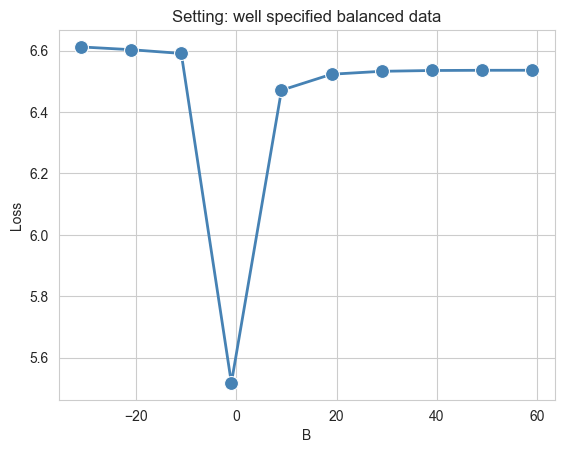

In [632]:
hyperparameter_analysis("well specified", "AIOLI", "B", n = 10)

200 samples were generated in the well specified balanced setting. Using 3 variables, with an average sigma of 0.493


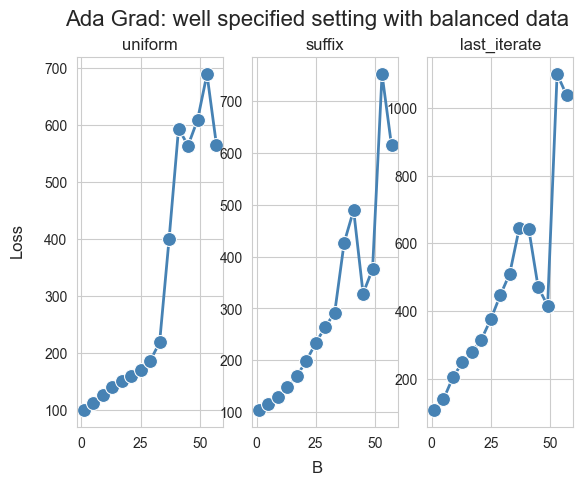

In [680]:
hyperparameter_analysis("well specified","ADAGRAD", "B")

## AIOLI B values

In [568]:
x_means = [2,1,5]
x = generate_x(200,3, means = x_means, seed = 40)
betas = [0.4,-0.3,-1.2]
# betas = [-0.2,0.5,0.8]
y = generate_y(200,x,betas = betas)

x_train = x[:150]
y_train = y[:150]
x_test = x[150:]
y_test = y[150:]
print(f"Average sigma(xb): {np.mean( [sig(xb) for xb in np.inner(x,betas)])}")
print(f"Sigma of average xb: {sig(np.inner(x_means,betas))}")
y_train
# y_test

Average sigma(xb): 0.005172482584757945
Sigma of average xb: 0.004070137715896127


array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [515]:
B_values = [x for x in range(-31,60,10)]
loss_B = np.zeros(len(B_values))

for i in range(len(B_values)):
    aioli_model = AIOLI()
    aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = B_values[i], minimize_method = "l-bfgs-b", dynamic_B = False)
    loss_B[i] = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

C:\Users\marie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\marie\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
C:\Users\marie\AppData\Local\Temp\ipykernel_14136\2445632335.py:128: RuntimeWarning: overflow encountered in exp
  etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)
C:\Users\marie\AppData\Local\Temp\ipykernel_14136\2445632335.py:135: RuntimeWarning: invalid value encountered in scalar multiply
  fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
C:\Users\marie\AppData\Local\Temp\ipykernel_14136\2445632335.py:136: RuntimeWarning: invalid value encountered in multiply
  eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
C:\Users\marie\AppData\Local\Temp\ipykernel_14136\2445632335.py:16: RuntimeWarning: invalid val

<Axes: xlabel='B_value', ylabel='Loss'>

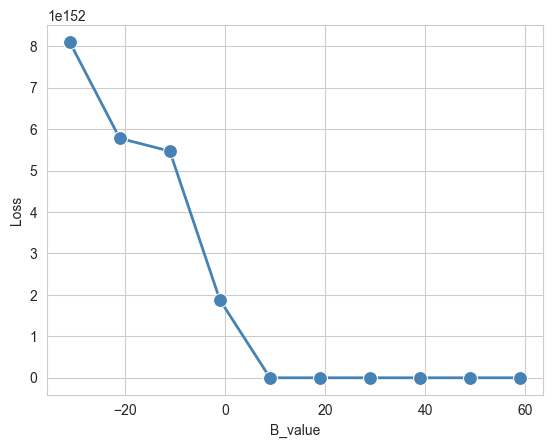

In [516]:
# Create DataFrame for seaborn
df = pd.DataFrame({
    'B_value': B_values,
    'Loss': loss_B
})

# Line plot with markers
sns.lineplot(data=df, x='B_value', y='Loss', marker='o', markersize=10,
             linewidth=2, color='steelblue')

# Functions for simulations

## Data class for specifying simulation configuration

In [371]:

@dataclass
class SimulationConfig:
    # Default is well specified
    runs: int = default_runs
    n: int = default_n
    d: int = 3
    data_seed: int = 40
    betas: list = field(default_factory=lambda: [2,0.1,-4.2]) # This is to create a new list every time.
    x_means: list = field(default_factory=lambda: [2,2,1])
    # These values of betas and x_means guarantee a P(Y=1) = 0.5, hence balanced classes.
    B: int = 30
    X: int = 90
    test_ratio: float = default_test_ratio
    minimize_method: str = "l-bfgs-b"
    y_method: str = "sigmoid"

## Function to run simulations and get results

In [372]:
def run_simulation(cfg: SimulationConfig):
    runs = cfg.runs
    n = cfg.n
    d = cfg.d
    betas = cfg.betas
    x_means = cfg.x_means
    B = cfg.B
    X = cfg.X
    test_ratio = cfg.test_ratio
    minimize_method = cfg.minimize_method
    y_method = cfg.y_method
    data_seed = cfg.data_seed

    # results_all = []
    test_set_results = []
    y_counts = []
    start_time = datetime.datetime.now()

    # Store y values to use later
    all_y_trains = {}
    all_y_tests = {}


    for i in range(runs):

        test_size = round(n * test_ratio)
        train_size = n - test_size
        # Generate data
        x = generate_x(n, d, means = x_means, seed = data_seed + i)
        y = generate_y(n, x, betas, seed = data_seed + i, method = y_method)

        # Split train/test
        x_train, y_train, x_test, y_test = x[:train_size], y[:train_size], x[train_size:], y[train_size:]

        # Store y counts to evaluate balance level later
        y_counts.append({
            "count_1": int(np.sum(y_train == 1)),
            "count_minus1": int(np.sum(y_train == -1))
        })

        # Generate data again if trainingset only has one class
        # y1_count_train = int(np.sum(y_train == 1))
        # while y1_count_train == n or y1_count_train ==0:
        #     print("Data re-generated only one class in training set")
        #     # Generate data
        #     x = generate_x(n, d, means = x_means, seed = data_seed + i)
        #     y = generate_y(n, x, betas, seed = data_seed + i, method = y_method)
        #
        #     # Store y counts to evaluate balance level later
        #     y_counts.append({
        #         "count_1": int(np.sum(y == 1)),
        #         "count_minus1": int(np.sum(y == -1))
        #     })
        #     # Split train/test
        #     x_train, y_train, x_test, y_test = x[:train_size], y[:train_size], x[train_size:], y[train_size:]
        #
        #     y1_count_train = int(np.sum(y_train == 1))

        # Store y values for later inspection
        all_y_trains[f"run_{i}"] = y_train.copy()
        all_y_tests[f"run_{i}"] = y_test.copy()


        # Get SMOTE dataset for unbalanced cases
        sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
        smote_x, smote_y = sm.apply_smote()

        # Run algorithms
        ogd = online_gd(data_y=y_train, data_x=x_train, B=B)
        adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(B/13,d))
        aioli_model = AIOLI()
        ai = aioli_model.fit(data_y=y_train, data_x=x_train, X=X, B=B/13, minimize_method = minimize_method)
        classic_lg = classic_logistic_regression(data_x=x_train, data_y=y_train)
        ridge_lg = ridge_logistic_regression(data_x=x_train, data_y=y_train)
        lasso_lg = lasso_logistic_regression(data_x=x_train, data_y=y_train)
        smp = sample_minmax_predictor(x_train, y_train)
        ridge_smp = ridge_sample_minmax_predictor(x_train, y_train)
        classic_lg_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)


        # OTB estimates
        # OGD
        OGD_OTB_uniform = calculate_OTB(ogd["All_Betas"], "uniform")
        OGD_OTB_Suffix  = calculate_OTB(ogd["All_Betas"], "suffix_averaging")
        OGD_OTB_lastit  = calculate_OTB(ogd["All_Betas"], "last_iterate")
        # AdaGrad
        adagrad_OTB_uniform = calculate_OTB(adagrad["All_Betas"], "uniform")
        adagrad_OTB_Suffix  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
        adagrad_OTB_lastit  = calculate_OTB(adagrad["All_Betas"], "last_iterate")

        ############################## TEST RESULTS ##############################
        # OGD
        loss_OGD_uniform_test = log_loss(OGD_OTB_uniform, x_test, y_test)
        loss_OGD_Suffix_test  = log_loss(OGD_OTB_Suffix,  x_test, y_test)
        loss_OGD_lastit_test  = log_loss(OGD_OTB_lastit,  x_test, y_test)

        # Adagrad
        loss_adagrad_uniform_test = log_loss(adagrad_OTB_uniform, x_test, y_test)
        loss_adagrad_Suffix_test  = log_loss(adagrad_OTB_Suffix,  x_test, y_test)
        loss_adagrad_lastit_test  = log_loss(adagrad_OTB_lastit,  x_test, y_test)

        # AIOLI
        loss_AIOLI_uniform_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
        loss_AIOLI_Suffix_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"]
        loss_AIOLI_lastit_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"]

        # Logistic Regression
        loss_LG_test = log_loss(classic_lg["Batch_estimate"], x_test, y_test)
        loss_LG_smote_test = log_loss(classic_lg_smote["Batch_estimate"], x_test, y_test)
        loss_LG_Ridge_test = log_loss(ridge_lg["Batch_estimate"],   x_test, y_test)
        loss_LG_Lasso_test = log_loss(lasso_lg["Batch_estimate"],   x_test, y_test)

        # SMP
        smp_result = smp.get_new_loss(x_test, y_test)
        ridge_smp_result = ridge_smp.get_new_loss(x_test, y_test)

        algorithms_test = {
            "Classical_LG":  {"loss": loss_LG_test},
            "Classical_LG_SMOTE":      {"loss": loss_LG_smote_test},
            "Ridge_LG":      {"loss": loss_LG_Ridge_test},
            "Lasso_LG":      {"loss": loss_LG_Lasso_test},
            "OGD_uniform": {"loss": loss_OGD_uniform_test},
            "OGD_Suffix":  {"loss": loss_OGD_Suffix_test},
            "OGD_Last_iterate": {"loss": loss_OGD_lastit_test},
            "AdaGrad_uniform": {"loss": loss_adagrad_uniform_test},
            "AdaGrad_Suffix":  {"loss": loss_adagrad_Suffix_test},
            "AdaGrad_Last_iterate": {"loss": loss_adagrad_lastit_test},
            "AIOLI_uniform": {"loss": loss_AIOLI_uniform_test},
            "AIOLI_Suffix":  {"loss": loss_AIOLI_Suffix_test},
            "AIOLI_lastit":  {"loss": loss_AIOLI_lastit_test},
            "SMP":      {"loss": smp_result["loss"]},
            "Ridge_SMP":      {"loss": ridge_smp_result["loss"]}
        }

        for name, metrics in algorithms_test.items():
             test_set_results.append({
                "run": i,
                "algorithm": name,
                **metrics
            })
        print(f"Run {i+1} finished")

    endtime = datetime.datetime.now()

    return {
            "test_results": pd.DataFrame(test_set_results),
            "y_counts_train": pd.DataFrame(y_counts),
            "y_train_df": pd.DataFrame(all_y_trains),
            "y_test_df": pd.DataFrame(all_y_tests),
            "total_time": (endtime - start_time).total_seconds()
        }


## Function for printing results

In [214]:
def print_results(results):
    # summary_train = results["final_results"].groupby("algorithm")[["runtime", "loss (trainset)", "online_loss", "betas"]].mean()
    # summary_train["betas"] = summary_train["betas"].apply(lambda array: np.round(array, 3))
    summary_test = results["test_results"].groupby("algorithm")[["loss"]].mean()
    print(f"Total time: {str(datetime.timedelta(seconds=results["total_time"]))}")
    # display(summary_train)
    display(summary_test)

## Function for graphing loss and Y=1 counts over runs

In [284]:
def plot_results(results, n = default_n):
    test_results = results["test_results"]

    # Boxplots of y counts
    sns.boxplot(data=results["y_counts_train"][["count_1", "count_minus1"]])
    plt.title("Distribution of Y counts across runs")
    plt.ylim(0, round(n*(1-default_test_ratio)))
    plt.show()

    # Distribution of y values
    print(results["y_train_df"].apply(pd.Series.value_counts))

    # Line plot of Loss over rounds
    sns.lineplot(x = test_results["run"], y = test_results["loss"], hue = test_results["algorithm"]).set_title("Loss over rounds")
    plt.show()


# Experiments

## Balanced

In [224]:
well_specified = SimulationConfig(
    n = default_n,
    d = 3,
    betas= bs_balanced,
    x_means= xs_balanced
)

well_specified_result = run_simulation(well_specified)
print_results(well_specified_result)

Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Lasso LG was fit manually
Run 3 finished
Lasso LG was fit manually
Run 4 finished
Lasso LG was fit manually
Run 5 finished
Total time: 0:05:44.818883


,loss
algorithm,
AIOLI_Suffix,10.273548
AIOLI_lastit,11.721123
AIOLI_uniform,9.799459
AdaGrad_Last_iterate,10.261129
AdaGrad_Suffix,10.131759
AdaGrad_uniform,9.143897
Classical_LG,10.018579
Classical_LG_SMOTE,10.169452
Lasso_LG,8.454963


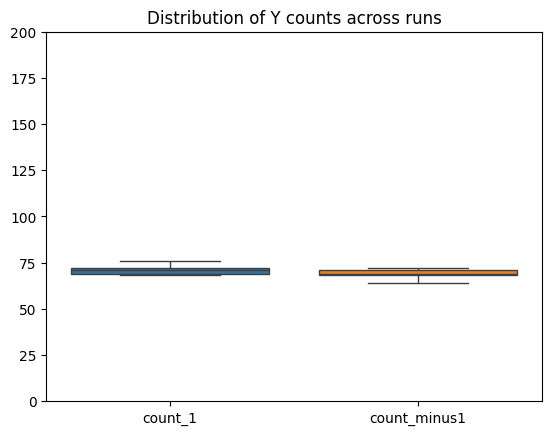

    run_0  run_1  run_2  run_3  run_4
-1     64     69     68     72     71
 1     76     71     72     68     69


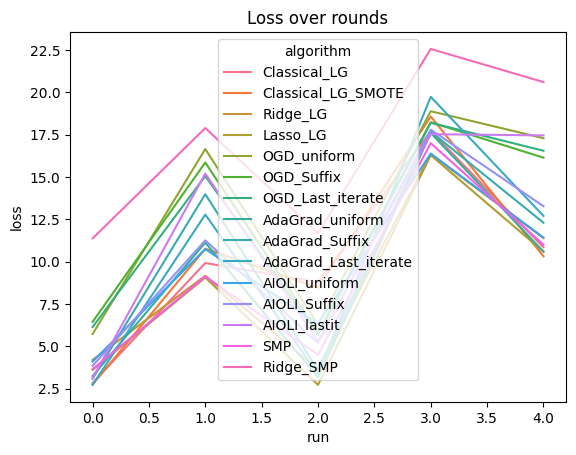

In [225]:
plot_results(well_specified_result, n = default_n)

In [226]:
high_dimensional = SimulationConfig(
    n = 20,
    d = 25,
    betas= bs_hd_balanced,
    x_means= xs_hd_balanced
)

high_dimensional_result = run_simulation(high_dimensional)
print_results(high_dimensional_result)

Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Lasso LG was fit manually
Run 3 finished
Lasso LG was fit manually
Run 4 finished
Lasso LG was fit manually
Run 5 finished
Total time: 0:00:36.333262


,loss
algorithm,
AIOLI_Suffix,3.837608
AIOLI_lastit,3.692076
AIOLI_uniform,3.951691
AdaGrad_Last_iterate,46.968397
AdaGrad_Suffix,68.305046
AdaGrad_uniform,89.189006
Classical_LG,8.839763
Classical_LG_SMOTE,9.218823
Lasso_LG,4.222595


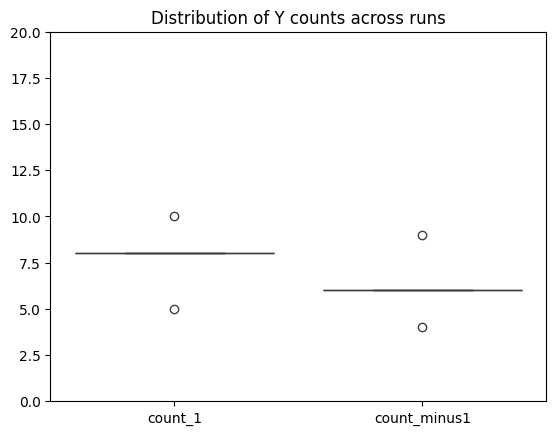

    run_0  run_1  run_2  run_3  run_4
-1     64     69     68     72     71
 1     76     71     72     68     69


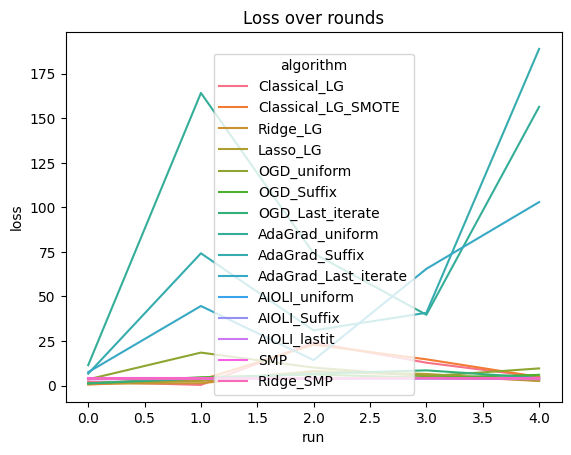

In [227]:
plot_results(high_dimensional_result, n = 20)

In [228]:
high_dimensionality = SimulationConfig(
    runs = 5,
    n = 50,
    d = 25,
    betas= bs_hd_balanced,
    x_means= xs_hd_balanced
)

high_dimensionality_result = run_simulation(high_dimensionality)
print_results(high_dimensionality_result)

Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Lasso LG was fit manually
Run 3 finished
Lasso LG was fit manually
Run 4 finished
Lasso LG was fit manually
Run 5 finished
Total time: 0:05:05.978174


,loss
algorithm,
AIOLI_Suffix,8.369167
AIOLI_lastit,7.749893
AIOLI_uniform,8.937981
AdaGrad_Last_iterate,130.520212
AdaGrad_Suffix,126.333590
AdaGrad_uniform,129.199859
Classical_LG,21.206989
Classical_LG_SMOTE,23.161479
Lasso_LG,8.044815


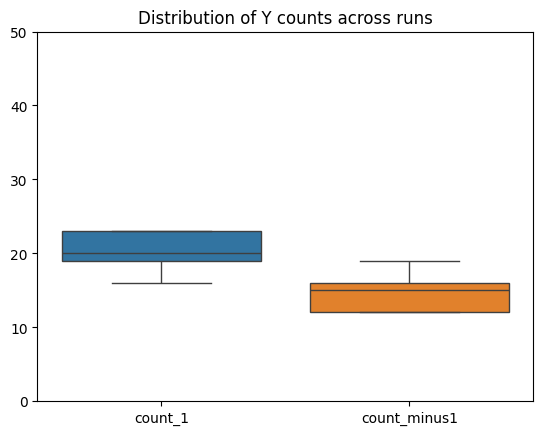

    run_0  run_1  run_2  run_3  run_4
-1     64     69     68     72     71
 1     76     71     72     68     69


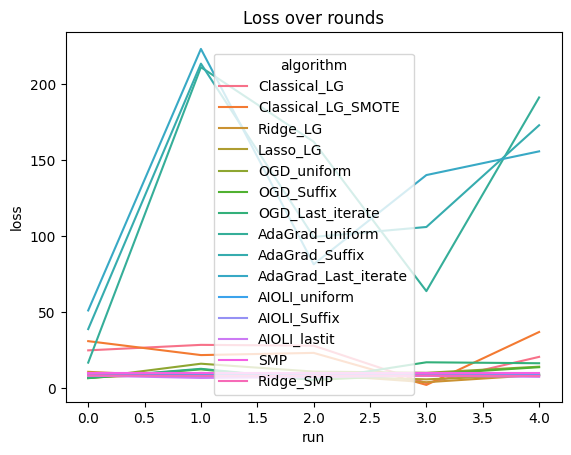

In [229]:
plot_results(high_dimensionality_result, n = 50)

In [230]:
sinusoidal = SimulationConfig(
    n = default_n,
    d = 3,
    betas= bs_balanced,
    x_means= xs_balanced,
    y_method = "sinusoidal"
)

sinusoidal_result = run_simulation(sinusoidal)
print_results(sinusoidal_result)

Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Dataset is balanced
Lasso LG was fit manually
Run 3 finished
Lasso LG was fit manually
Run 4 finished
Lasso LG was fit manually
Run 5 finished
Total time: 0:03:53.377581


,loss
algorithm,
AIOLI_Suffix,45.322643
AIOLI_lastit,48.206759
AIOLI_uniform,42.533773
AdaGrad_Last_iterate,55.745801
AdaGrad_Suffix,46.177484
AdaGrad_uniform,48.088612
Classical_LG,42.157025
Classical_LG_SMOTE,42.320996
Lasso_LG,42.085951


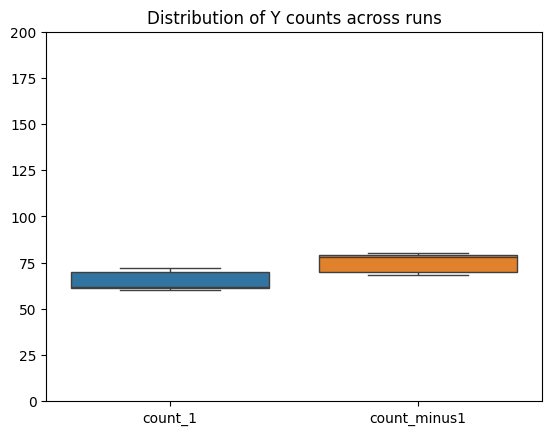

    run_0  run_1  run_2  run_3  run_4
-1     64     69     68     72     71
 1     76     71     72     68     69


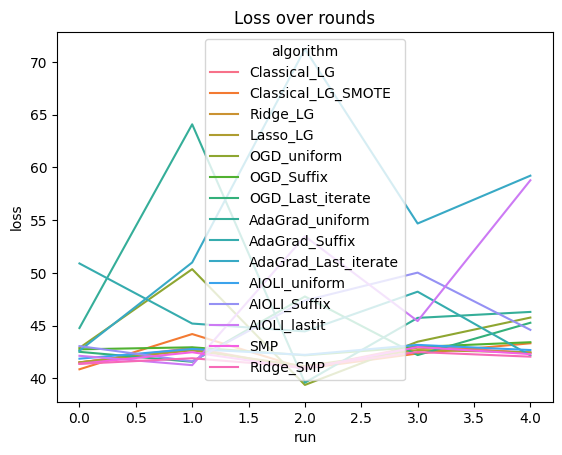

In [231]:
plot_results(sinusoidal_result)

In [232]:
quadratic = SimulationConfig(
    n = default_n,
    d = 3,
    betas= bs_balanced,
    x_means= xs_balanced,
    y_method = "quadratic"
)

quadratic_result = run_simulation(quadratic)
print_results(quadratic_result)

Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Lasso LG was fit manually
Run 3 finished
Lasso LG was fit manually
Run 4 finished
Lasso LG was fit manually
Run 5 finished
Total time: 0:03:20.409904


,loss
algorithm,
AIOLI_Suffix,37.267905
AIOLI_lastit,38.130233
AIOLI_uniform,42.710827
AdaGrad_Last_iterate,42.565401
AdaGrad_Suffix,38.423541
AdaGrad_uniform,46.984373
Classical_LG,35.691854
Classical_LG_SMOTE,37.874286
Lasso_LG,35.972232


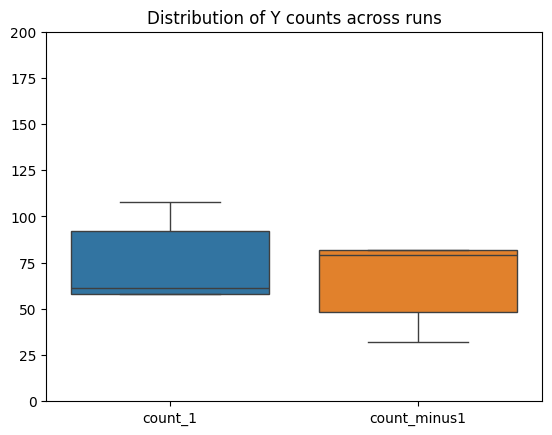

    run_0  run_1  run_2  run_3  run_4
-1     64     69     68     72     71
 1     76     71     72     68     69


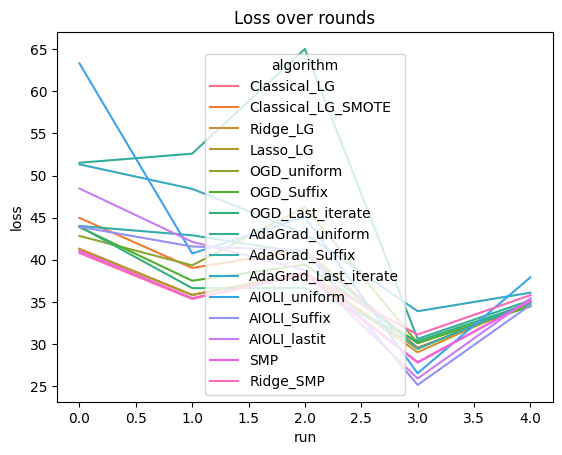

In [233]:
plot_results(quadratic_result)

## Unbalanced

### X means and betas for unbalanced data $P(Y=1)$ -> 1 or 0)


In [234]:

# Unbalanced
bs_unbalanced = [1.5,0.1,-4.2]
xs_unbalanced = [2,2,1]
print(np.inner(bs_unbalanced,xs_unbalanced))
print(sig(np.inner(bs_unbalanced,xs_unbalanced)))
print((1/2)*np.sin(np.inner(xs_unbalanced,bs_unbalanced)) + 1/2)


-1.0
0.2689414213699951
0.07926450759605175


In [502]:
1/200 # TO DO try this for unbalanced. (1/n)

0.005

In [274]:
#unbalanced quadratic
xs_unbalanced_quadratic = np.array([1.45,0.5,1.1])
print(sig(np.inner(bs_unbalanced,xs_unbalanced_quadratic**2)))


0.12974108050537173


In [278]:
# Unbalanced High dimensional (25 variables)
bs_hd_unbalanced = [2,1.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7]

xs_hd_unbalanced = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]


print(len(bs_hd_unbalanced), len(xs_hd_unbalanced))
# print(np.inner(bs_hd_unbalanced,xs_hd_unbalanced))
print(sig(np.inner(bs_hd_unbalanced,xs_hd_unbalanced)))
print((1/2)*np.sin(np.inner(xs_hd_unbalanced,bs_hd_unbalanced)) + 1/2)

25 25
0.8889440332885924
0.9365664897537582


### Experiments

In [282]:
well_specified_unbalanced = SimulationConfig(
    n = default_n,
    betas= bs_unbalanced,
    x_means= xs_unbalanced
)

well_specified_unbalanced_result = run_simulation(well_specified_unbalanced)
print_results(well_specified_unbalanced_result)

Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Lasso LG was fit manually
Run 3 finished
Lasso LG was fit manually
Run 4 finished
Lasso LG was fit manually
Run 5 finished
Total time: 0:05:46.631945


,loss
algorithm,
AIOLI_Suffix,33.974270
AIOLI_lastit,51.905183
AIOLI_uniform,32.145355
AdaGrad_Last_iterate,40.036696
AdaGrad_Suffix,33.075535
AdaGrad_uniform,35.741063
Classical_LG,30.856895
Classical_LG_SMOTE,31.498016
Lasso_LG,30.533914


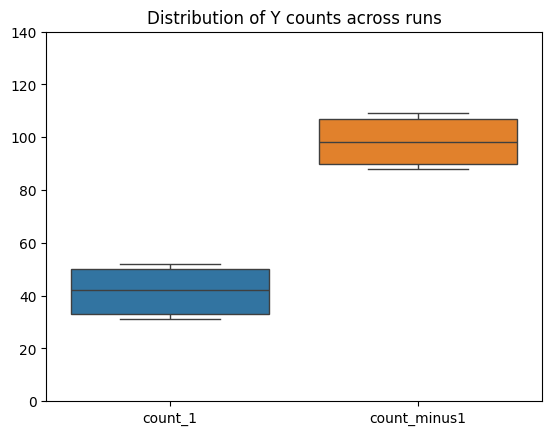

    run_0  run_1  run_2  run_3  run_4
-1     88    107     90    109     98
 1     52     33     50     31     42


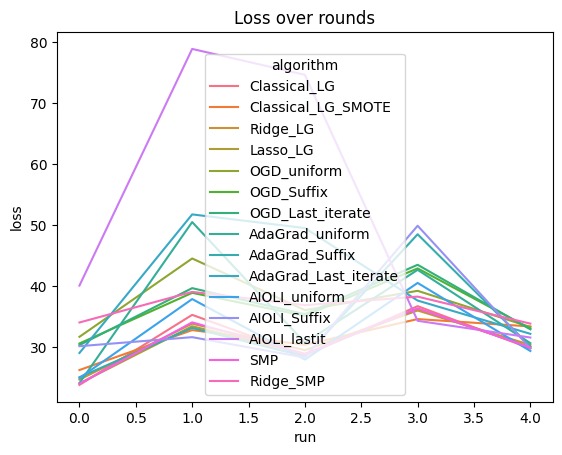

In [285]:
plot_results(well_specified_unbalanced_result)

In [238]:
high_dimensional_unbalanced = SimulationConfig(
    n = 20,
    d = 25,
    betas= bs_hd_unbalanced,
    x_means= xs_hd_unbalanced
)

high_dimensional_unbalanced_result = run_simulation(high_dimensional_unbalanced)
print_results(high_dimensional_unbalanced_result)


Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Lasso LG was fit manually
Run 3 finished
Lasso LG was fit manually
Run 4 finished
Lasso LG was fit manually
Run 5 finished
Total time: 0:00:19.880676


,loss
algorithm,
AIOLI_Suffix,3.834441
AIOLI_lastit,3.711485
AIOLI_uniform,3.950612
AdaGrad_Last_iterate,64.457825
AdaGrad_Suffix,80.384302
AdaGrad_uniform,89.729134
Classical_LG,9.855742
Classical_LG_SMOTE,10.347732
Lasso_LG,4.857952


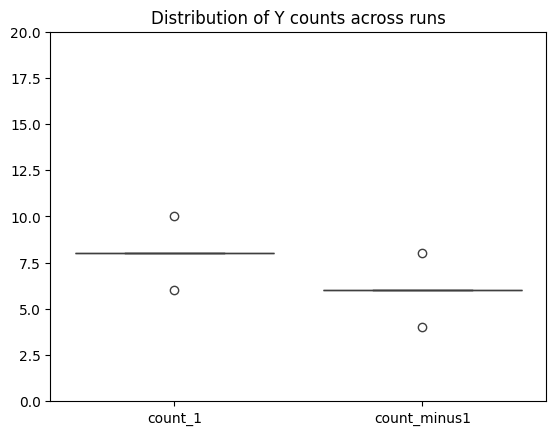

    run_0  run_1  run_2  run_3  run_4
-1     64     69     68     72     71
 1     76     71     72     68     69


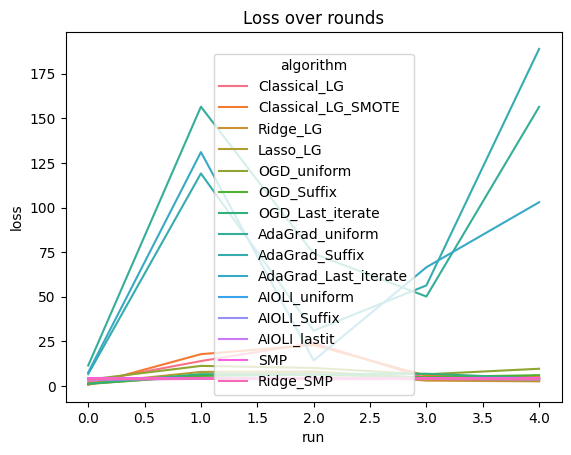

In [239]:
plot_results(high_dimensional_unbalanced_result, n = 20)

In [240]:
high_dimensionality_unbalanced = SimulationConfig(
    n = 50,
    d = 25,
    betas= bs_hd_unbalanced,
    x_means= xs_hd_unbalanced
)

high_dimensionality_unbalanced_result = run_simulation(high_dimensionality_unbalanced)
print_results(high_dimensionality_unbalanced_result)


Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Lasso LG was fit manually
Run 3 finished
Lasso LG was fit manually
Run 4 finished
Lasso LG was fit manually
Run 5 finished
Total time: 0:03:04.832604


,loss
algorithm,
AIOLI_Suffix,8.410528
AIOLI_lastit,7.881042
AIOLI_uniform,8.938371
AdaGrad_Last_iterate,123.758669
AdaGrad_Suffix,123.040148
AdaGrad_uniform,103.379794
Classical_LG,28.227089
Classical_LG_SMOTE,26.324952
Lasso_LG,9.295684


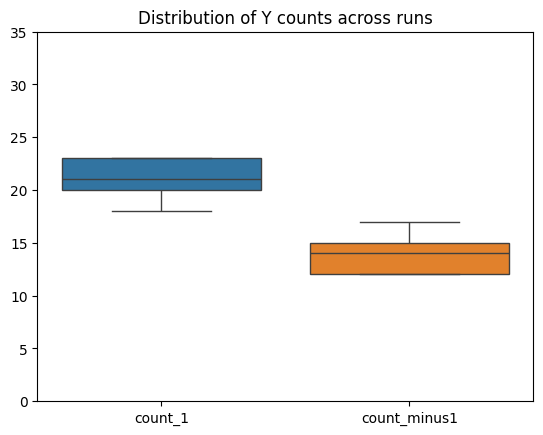

    run_0  run_1  run_2  run_3  run_4
 1     21     18     23     20     23
-1     14     17     12     15     12


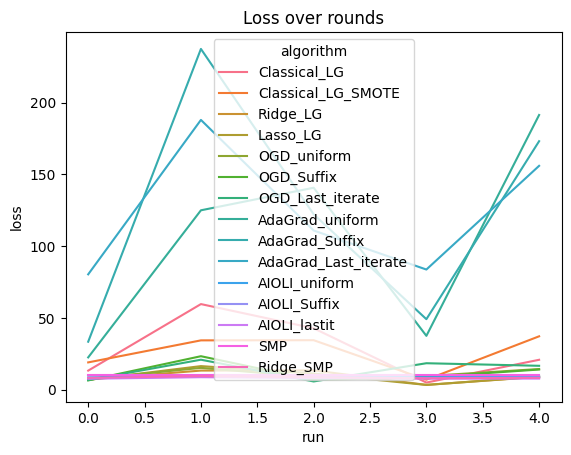

In [286]:
plot_results(high_dimensionality_unbalanced_result, n =50)

In [288]:
sinusoidal_unbalanced = SimulationConfig(
    d = 3,
    betas= bs_unbalanced,
    x_means= xs_unbalanced,
    y_method = "sinusoidal"
)

sinusoidal_unbalanced_result = run_simulation(sinusoidal_unbalanced)
print_results(sinusoidal_unbalanced_result)

Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Lasso LG was fit manually
Run 3 finished
Lasso LG was fit manually
Run 4 finished
Lasso LG was fit manually
Run 5 finished
Total time: 0:04:23.367658


,loss
algorithm,
AIOLI_Suffix,33.428811
AIOLI_lastit,49.110347
AIOLI_uniform,32.976382
AdaGrad_Last_iterate,42.463885
AdaGrad_Suffix,34.399044
AdaGrad_uniform,34.997363
Classical_LG,31.206935
Classical_LG_SMOTE,33.522186
Lasso_LG,32.133571


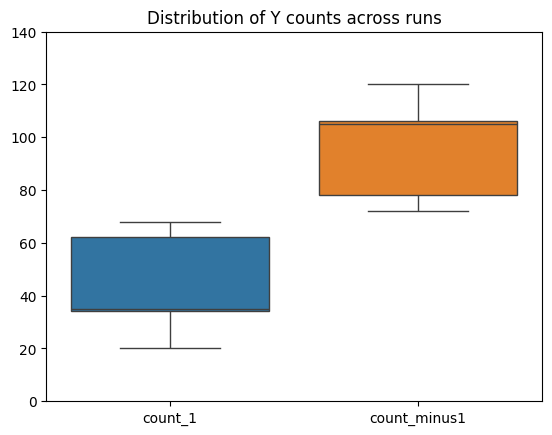

    run_0  run_1  run_2  run_3  run_4
-1     72    106     78    120    105
 1     68     34     62     20     35


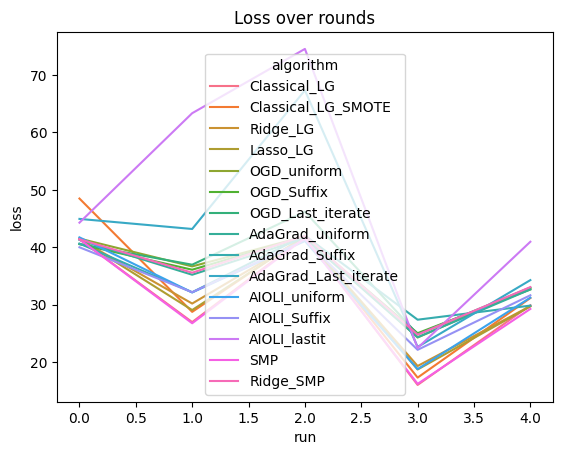

In [292]:
plot_results(sinusoidal_unbalanced_result)

In [275]:
quadratic_unbalanced = SimulationConfig(
    n = default_n,
    d = 3,
    betas= bs_unbalanced,
    x_means= xs_unbalanced_quadratic,
    y_method = "quadratic"
)

quadratic_unbalanced_result = run_simulation(quadratic_unbalanced)
print_results(quadratic_unbalanced_result)

Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Lasso LG was fit manually
Run 3 finished
Lasso LG was fit manually
Run 4 finished
Lasso LG was fit manually
Run 5 finished
Total time: 0:05:08.093852


,loss
algorithm,
AIOLI_Suffix,19.895047
AIOLI_lastit,22.829487
AIOLI_uniform,20.161624
AdaGrad_Last_iterate,28.966007
AdaGrad_Suffix,22.772861
AdaGrad_uniform,25.003492
Classical_LG,19.937817
Classical_LG_SMOTE,20.448641
Lasso_LG,19.781685


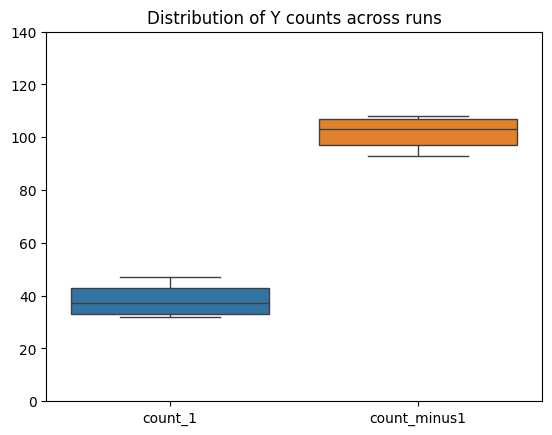

    run_0  run_1  run_2  run_3  run_4
-1     64     69     68     72     71
 1     76     71     72     68     69


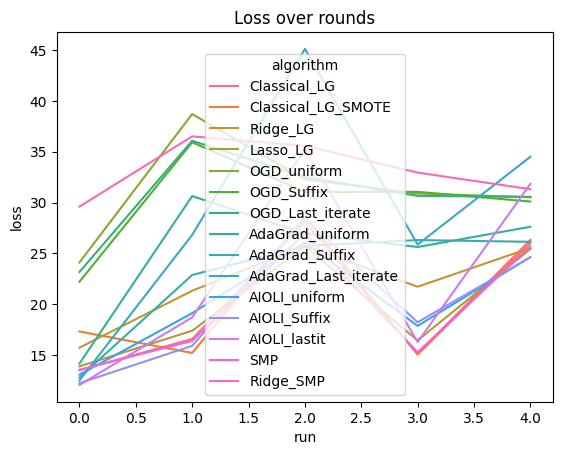

In [276]:
plot_results(quadratic_unbalanced_result)

## Graphing different data generating functions

In [244]:
# print(np.inner([1.5, 1.6, 0.7],[1.2, -0.9, -0.4]))
# bs_balanced = [2,0.1,-4.2]
# xs_balanced = [2,2,1]
# print(np.inner(bs_balanced,xs_balanced))

In [245]:
# x_s = generate_x(100,d = 3, means = [0.5, 0.8, 0.4], correlated = False)
# betas_s = [1.2, 0.9, 0.4]
# y_s = generate_y(100,x_s,betas_s)
# # p_s = [sig(dot) for dot in np.inner(x_s,betas_s)]
# # print(np.std(p_s))
# # print(np.mean(p_s))
# pd.Series(y_s).value_counts()

In [246]:
# y_s = generate_y(100,x_s,betas_s, enrique = False)

In [247]:
# for i in range(x_s.shape[1]):
#     sns.scatterplot(x = range(len(x_s[:,i])), y = [sig(np.inner(x,betas_s)) for x in x_s] )
#     plt.title(f"P(Y=1) over x{i}")
#     plt.show()

In [248]:
# i = 0
# [np.inner(x,betas_s) for x in x_s]


In [249]:


# sig(np.inner(x_s[4],betas_s))
#y_s = generate_y(n = 100,x = x_s, betas = betas_s)

#sns.scatterplot(x = x_s[:,0].flatten(), y = y_s)

In [250]:

# sns.lineplot(x = x_s[:,1].flatten(), y = y_s)

In [251]:
# sns.lineplot(x = x_s[:,2].flatten(), y = y_s)

In [252]:
# x_s[:,0].flatten()

In [253]:

# Data
# y = np.array([1,1,1,1,1,1,1,1,1])
# X = np.array([
#     [1,3,2],
#     [2,3,6],
#     [3,1,4],
#     [1,0,2],
#     [0,1,1],
#     [2,2,2],
#     [3,3,1],
#     [1,1,1],
#     [2,3,1]
# ])
#
# # Negative log-likelihood (sigmoid applied inline)
# def neg_loglik(beta):
#     z = X @ beta
#     p = 1 / (1 + np.exp(-z))          # sigmoid inline
#     #p = np.clip(p, 1e-12, 1 - 1e-12)  # numerical stability
#     return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
#
# # Initial guess
# beta0 = np.zeros(X.shape[1])
#
# # Optimize
# res = minimize(neg_loglik, beta0, method="BFGS")
#
# print("Optimal beta:", res.x)
# print("Converged:", res.success)
# print("Final negative log-likelihood:", res.fun)


### Check AIOLI convergence

In [254]:
#round((final_results[final_results["algorithm"] == "AIOLI_uniform"]["convergence"].mean() * 100 / n).item(),2)

In [255]:
#round((final_results[final_results["algorithm"] == "AIOLI_uniform"]["minimizer_gradient"].mean() * 100 / n).item(),2)

# Ignore from here on, it's simply code to test some functions/debugging

## Tests

In [256]:
#etas = np.array([1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3)])
#xt = np.array([1,2,3])
#betas = np.array([[2,2,5],[1,1,3],[4,5,6]])
#reg_lambda = 0.3
#gradients = np.array([[2,2,5],[1,1,3],[4,5,6]])
#b = np.array([1,2,3])
#sum_loss = 5


#(sum(etas)/2)*np.inner((b-betas[2]),gradients[2])*np.inner(gradients[2],(b-betas[2]))
#np.linalg.norm(etas)


In [257]:
#diff = b - betas
#inner_prod = np.sum(gradients * diff,axis = 1)
#np.sum(np.sum(etas)/2 * inner_prod**2)

In [258]:
# x0 = np.array([0,0,0])

#res = minimize(parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, reg_lambda, sum_loss,first_sum, etas_gradients))
#parameter_function_AIOLI(x0, xt, betas, etas, reg_lambda, sum_loss,gradients)
#res.x

In [259]:
# diff = b - betas
# gs_bs = np.sum(gradients * diff,axis = 1)
# quadratic = np.sum(np.sum(etas)/2 * gs_bs**2)
#
# l_hat = sum_loss + np.sum(gs_bs) + quadratic
#
# l_hat + np.log(1+np.exp(np.inner(b,xt))) + np.log(1+np.exp(np.inner(-b,xt))) + reg_lambda*np.linalg.norm(b)

## Generate data

In [260]:
# n = 1000
#
# mean = [20, 5, 2]
# cov = [[1, 0, 0], [0, 3, 0], [0,0,2]]  # diagonal covariance
# d = np.shape(cov)[1]
# y = np.random.binomial(n=1, p=0.3, size=n)
#
# x1, x2, x3 = np.random.multivariate_normal(mean, cov, size = n).T
# plt.plot(x1, x2, 'x')
# plt.axis('equal')
# plt.show()
#
# plt.plot(x1, x3, 'x')
# plt.axis('equal')
# plt.show()


In [261]:
# x = np.random.multivariate_normal(mean, cov, size = n)
# sns.countplot(x=y)
# plt.show()


In [262]:
# np.log(1000)

## OTB conversion proof tests

In [263]:
# weights = np.array([0.3,0.7])
# values = np.array([2,3])
#
# print(np.sum(values))
# print(np.sum(weights*values))